In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [3]:
# AT --> temprature
# V --> vacuum
# AP --> Presure
# RH --> Humidity

# PE --> Produce Energy

In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X = df.drop(['PE'],axis='columns')
y = df.PE

In [6]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [7]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]])

In [11]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]])

In [12]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [13]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [14]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)

test_loader = DataLoader(test_dataset,batch_size=32)

Deep Learning

In [15]:
# define ANN model

class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(
            # 1 Hidden Layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            # 2 Hidden Layer
            nn.Linear(6,6),
            nn.ReLU(),

            # output Layer 
            nn.Linear(6,1),
        )

    def forward(self,x):
        return self.model(x)
        

In [16]:
import torch.optim as optim

model = ANN()

# Losss, Optimizer
criterian = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [17]:
# Train the ANN

train_losses = []
valid_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # total training loss for 1 epoch

    for xb, yb, in train_loader:
        # xb --> features of 1 batch
        # yb --> label of 1 batch

        optimizer.zero_grad()

        outputs = model(xb) # forward prop..... predicted output for this batch
        loss = criterian(outputs , yb) # compute loss
        loss.backward()  # backward prop.... compute gradient
        optimizer.step() # params update

        running_loss += loss.item() # loss is tensor --> py float

    epoch_train_losses = running_loss/len(train_loader)
    train_losses.append(epoch_train_losses)

    # validattion
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradient compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterian(outputs , yb) 
            running_val_loss += loss

    epoch_test_losses = running_val_loss / len(test_loader)
    valid_losses.append(epoch_test_losses)

    print(f" epoch {epoch+1}/ {epochs} ==> train loss {epoch_train_losses} & val loss {epoch_test_losses} ")

    if epoch_test_losses < best_val_loss:
        best_val_loss = epoch_test_losses
        torch.save(model.state_dict(), "best_model.pt") # pt pth

 epoch 1/ 100 ==> train loss 204894.52233072917 & val loss 201333.078125 
 epoch 2/ 100 ==> train loss 190695.69537760416 & val loss 174952.671875 
 epoch 3/ 100 ==> train loss 150517.28883463543 & val loss 124303.5390625 
 epoch 4/ 100 ==> train loss 99335.79197591146 & val loss 79252.15625 
 epoch 5/ 100 ==> train loss 65032.19827473958 & val loss 54435.97265625 
 epoch 6/ 100 ==> train loss 44501.67925618489 & val loss 35855.74609375 
 epoch 7/ 100 ==> train loss 27614.43702392578 & val loss 20696.642578125 
 epoch 8/ 100 ==> train loss 15417.381512451171 & val loss 11510.1044921875 
 epoch 9/ 100 ==> train loss 9105.410182698568 & val loss 7351.57568359375 
 epoch 10/ 100 ==> train loss 6145.755641682943 & val loss 5169.83935546875 
 epoch 11/ 100 ==> train loss 4376.9496287028 & val loss 3756.761474609375 
 epoch 12/ 100 ==> train loss 3186.5260075887045 & val loss 2797.3896484375 
 epoch 13/ 100 ==> train loss 2377.6950205485027 & val loss 2147.038330078125 
 epoch 14/ 100 ==> tr

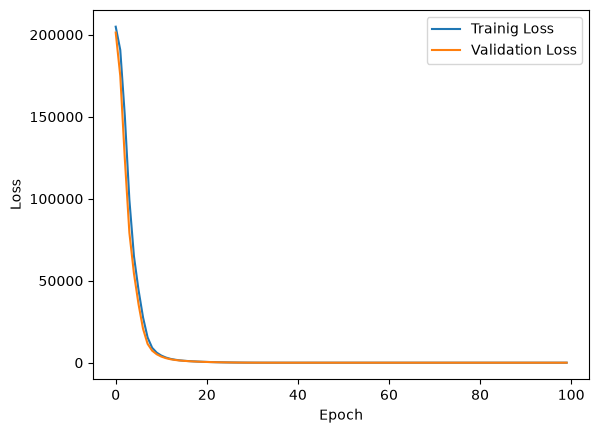

In [18]:
import matplotlib.pyplot as plt

df_loss = pd.DataFrame({
    "Trainig Loss" : train_losses,
    "Validation Loss" : valid_losses
})

plt.plot(df_loss["Trainig Loss"], label = "Trainig Loss")
plt.plot(df_loss["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

In [19]:
# Loading the best model

model.load_state_dict(torch.load("best_model.pt"))

C:\Users\Mohd Zaid\AppData\Local\Temp\ipykernel_19808\3488237182.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt"))


<All keys matched successfully>

In [23]:
# Evaluate our Model 

model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)

    train_mse_loss = criterian(train_pred, y_train_tensor)
    test_mse_loss = criterian(test_pred, y_test_tensor)

print("Training MSE: ", train_mse_loss.item())
print("Testing MSE: ", test_mse_loss.item())

Training MSE:  21.207353591918945
Testing MSE:  19.55592918395996


In [24]:
from sklearn.metrics import r2_score

print("r2_score: ",r2_score(y_test,test_pred))

r2_score:  0.9316570827262618


In [27]:
predicted_value = pd.DataFrame(test_pred.numpy(), columns=["Predicted Value"])
acutal_value = pd.DataFrame(y_test.values, columns=["Actual Value"])

pd.concat([predicted_value, acutal_value], axis=1)

,Predicted Value,Actual Value
0,435.265808,433.27
1,437.285980,438.16
2,460.913055,458.42
3,475.985443,480.82
4,435.266937,441.41
...,...,...
1909,451.337799,456.70
1910,431.811493,438.04
1911,467.484253,467.80
1912,431.337738,437.14
